In [1]:
import matplotlib.pyplot as plt
from ESN import Reservoir
from narma import NARMA
from Qreservoir_fast import QReservoir
from tools import init_identity, tensor, partial_transpose, negativity, dagger, gen_input_states, init_two_mode_th, init_th, init_two_mode_sq, init_two_mode_sq_th, init_destroy, assess_dm_entanglement, entanglement

import numpy as np
import qutip as qt
import scipy as sp
import copy
import time

#Pyörittelyt --------------------------------------------------------

In [2]:
classic = Reservoir(128)
classic.add_performance_task(NARMA(degree_=6))
classic.generate_inputs([1000,3000,5000])
classic.evolve_reservoir('task1', 'full')
classic.results['task1']

Added performance task 'NARMA(6, 0.3, 0.05, 0.375, 0)' as 'task1'


('NARMA(6, 0.3, 0.05, 0.375, 0)', np.float64(0.01258035121895656))

In [ ]:
for i in range(50):
    jeps = Reservoir(128, 0.9, 0.1)
    jeps.add_performance_task(NARMA(degree_=6))
    jeps.generate_inputs([1000,5000,3000])
    jeps.evolve_reservoir('task1', 'full')
    print(jeps.results['task1'])

In [7]:
quantum = QReservoir(1, 5, 5, "alltoall")
quantum.init_reservoir("vacuum")
quantum.init_unitary_evolution()
quantum.rk4_timesteps(2)

inputs = gen_input_states("sq_th", 10, 5)

In [8]:
quantum.train_reservoir(inputs)

0


KeyboardInterrupt: 

In [7]:
quantum.train_measured_observables_

array([[1.18624661e-01, 1.06152380e-01],
       [1.36547199e-01, 1.25631101e-01],
       [1.55988136e-01, 1.41377425e-01],
       [1.60667218e-01, 1.48522391e-01],
       [1.76958292e-01, 1.62072020e-01],
       [1.85570414e-01, 1.71699390e-01],
       [2.15572269e-01, 1.94705748e-01],
       [2.36355615e-01, 2.14456587e-01],
       [2.37824153e-01, 2.21008913e-01],
       [2.57629943e-01, 2.37655885e-01],
       [2.94308018e-01, 2.67139977e-01],
       [2.97776472e-01, 2.76907140e-01],
       [3.34447902e-01, 3.05630405e-01],
       [3.60331658e-01, 3.30844490e-01],
       [3.84489193e-01, 3.54210481e-01],
       [4.15242782e-01, 3.81823910e-01],
       [4.87913384e-01, 4.38351602e-01],
       [4.97267311e-01, 4.59094038e-01],
       [5.49233307e-01, 5.01164681e-01],
       [5.69590516e-01, 5.27492983e-01],
       [6.28285420e-01, 5.76005805e-01],
       [6.91848698e-01, 6.32442965e-01],
       [7.37314487e-01, 6.77882050e-01],
       [8.03210145e-01, 7.36559430e-01],
       [8.993133

In [4]:
new_inputs = gen_input_states("sq_th", 200, 5)

In [5]:
quantum.test_reservoir(new_inputs)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
0.465


0.465

In [6]:
for i in range(quantum.test_pre_Y_pred_.shape[1]):
    print(quantum.test_pre_Y_pred_[0][i],quantum.test_pre_Y_pred_[1][i])

0.52292049098729 0.47707950901271
0.53086563048574 0.46913436951425996
0.5320936023795739 0.4679063976204261
0.529048829024375 0.470951170975625
0.5380490019246581 0.4619509980753419
0.525678734800685 0.47432126519931495
0.5322413485106817 0.4677586514893183
0.5213395120289929 0.47866048797100713
0.531854256907554 0.4681457430924461
0.5323297805434464 0.4676702194565536
0.5323865609508948 0.46761343904910524
0.5382721862989687 0.46172781370103133
0.5266195636065162 0.4733804363934838
0.5276136271186439 0.4723863728813561
0.5309146049911765 0.46908539500882357
0.5280989416226272 0.47190105837737284
0.5263889479109971 0.47361105208900284
0.5254742427038457 0.47452575729615437
0.5287421139078281 0.47125788609217195
0.5332427732482009 0.46675722675179904
0.5299565221616799 0.4700434778383201
0.5350504534147622 0.46494954658523774
0.5404338416108816 0.45956615838911846
0.538298794876994 0.4617012051230061
0.5385251978965118 0.4614748021034883
0.5318524173052652 0.4681475826947347
0.53607955

In [5]:
jeps = np.array([[1,2,3],[4,5,6],[1,2,3]])
japs = np.array([[1,0,2],[4,3,1],[0,0,2]])


jaa = [np.array([[1,0],[0,1]]), *[np.diag([i,i]) for i in range(1, 3)]]
jaa

[array([[1, 0],
        [0, 1]]),
 array([[1, 0],
        [0, 1]]),
 array([[2, 0],
        [0, 2]])]

In [20]:
eka = np.random.uniform(-10,10,(400,400))

aikayks = time.perf_counter()
toka = eka + eka
time.sleep(2)
print(time.perf_counter()-aikayks)


2.002843499998562


In [9]:
sum(quantum.train_Y_true_[:,1])

np.int64(94)

In [2]:
amount_of_states = 10000
truncate = 5
reservoir_size = 4

theta_sq_th_ = np.random.uniform(0,2*np.pi,(amount_of_states,))
s_sq_th_ = np.random.uniform(0.8,0.95,(amount_of_states,))
phi_sq_th_ = np.random.uniform(0.5-np.pi/10, 0.5+np.pi/10, (amount_of_states,))
abs_alpha_sq_th_ = np.array([x*np.sin(y) for x, y in zip(s_sq_th_,phi_sq_th_)])
alpha_sq_th_ = np.array([x*np.sin(y)*np.exp(1j*z) for x, y, z in zip(s_sq_th_,phi_sq_th_,theta_sq_th_)])
mean_n_sq_th_ = np.array([x*x*np.cos(y)*np.cos(y) for x, y in zip(s_sq_th_,phi_sq_th_)])

a1 = tensor([init_destroy(truncate), init_identity(truncate)])
a2 = tensor([init_identity(truncate), init_destroy(truncate)])

In [3]:
inputs = [init_two_mode_sq_th(x, y, truncate, a1, a2) for x, y in zip(alpha_sq_th_,mean_n_sq_th_)]
pt_inputs = [partial_transpose(input, "first", 5, 5) for input in inputs]

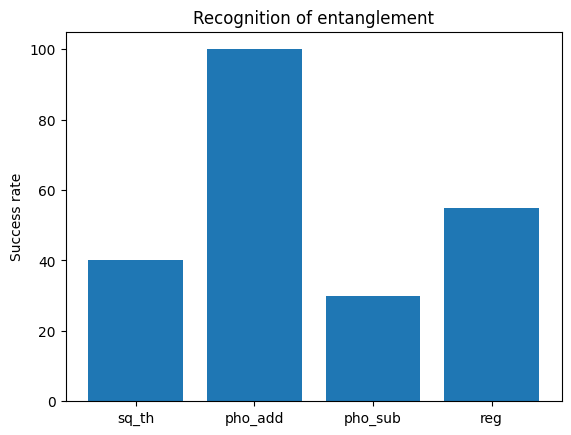

In [ ]:
#Plot the probability of correct classification
fig, ax = plt.subplots()

input_types = ['sq_th', 'pho_add', 'pho_sub', 'reg']
counts = [40, 100, 30, 55]
ax.bar(input_types, counts)

ax.set_ylabel('Success rate')
ax.set_title('Recognition of entanglement')

plt.show()